In [1]:
import os
import shutil
import random

SPLIT_DATASET_DIR = r"c:\Users\SAHIL\OneDrive\Desktop\DL project new\dataset_split"


In [2]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET_DIR, 'train'),
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET_DIR, 'val'),
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DATASET_DIR, 'test'),
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 2528 files belonging to 4 classes.
Found 541 files belonging to 4 classes.
Found 545 files belonging to 4 classes.
Classes: ['Bike', 'Bus', 'Car', 'Truck']
Number of classes: 4


In [3]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [4]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.2),
])

In [5]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import models

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [7]:
from tensorflow.keras import callbacks

checkpoint = callbacks.ModelCheckpoint(
    "efficientnetb0_new_split.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stopping = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - accuracy: 0.7481 - loss: 0.7245
Epoch 1: val_accuracy improved from None to 0.97967, saving model to efficientnetb0_new_split.keras

Epoch 1: finished saving model to efficientnetb0_new_split.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 29s 286ms/step - accuracy: 0.8730 - loss: 0.4443 - val_accuracy: 0.9797 - val_loss: 0.1227
Epoch 2/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.9545 - loss: 0.1711
Epoch 2: val_accuracy improved from 0.97967 to 0.98521, saving model to efficientnetb0_new_split.keras

Epoch 2: finished saving model to efficientnetb0_new_split.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 22s 273ms/step - accuracy: 0.9612 - loss: 0.1545 - val_accuracy: 0.9852 - val_loss: 0.0809
Epoch 3/15
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9697 - loss: 0.1205
Epoch 3: val_accuracy did not improve from 0.98521
79/79 ━━━━━━━━━━━━━━━━━━━━ 21s 261ms/step - accuracy: 0.9739 - loss: 0.1110 - val_accuracy: 0.9852 - val_loss: 0.0702
Ep

In [8]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 4s 197ms/step - accuracy: 0.9890 - loss: 0.0394
Test Accuracy: 98.90%


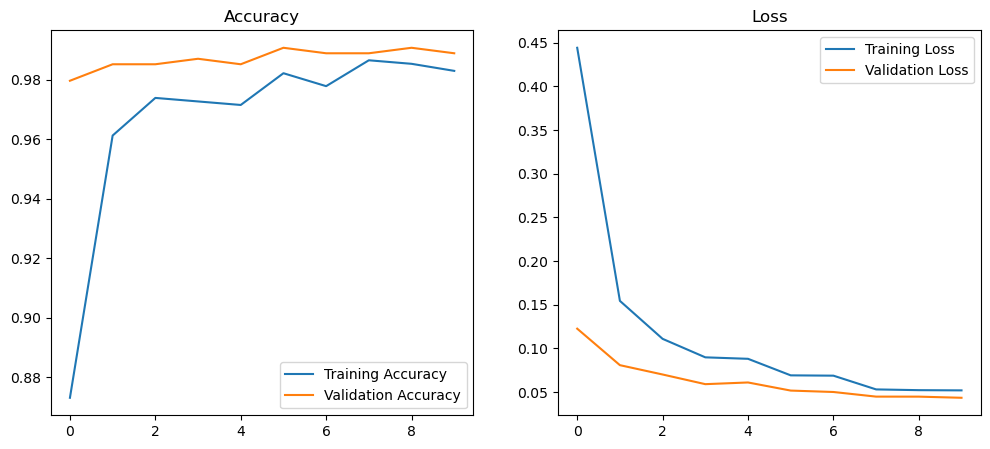

In [9]:
import matplotlib.pyplot as plt

history_dict = history.history

acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss_val = history_dict['loss']
val_loss = history_dict['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_val, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


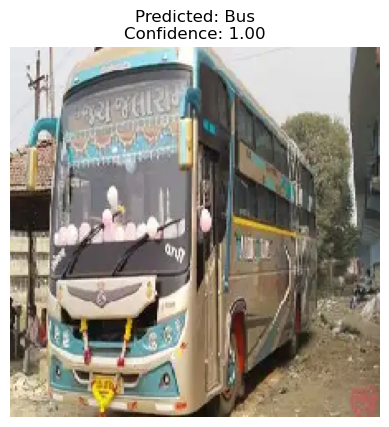

Predicted Class: Bus
Confidence: 0.9986135


In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# 🔹 Load trained model
model = tf.keras.models.load_model("efficientnetb0_new_split.keras")

# 🔹 Define class names (IMPORTANT: same order as training)
 # or manually define if needed

# 🔹 Path of image to predict
img_path = r"bustest3.webp"   # 🔥 change this

# 🔹 Load and preprocess image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # shape (1, 224, 224, 3)

# 🔹 Predict
predictions = model.predict(img_array)
predicted_class = class_names[np.argmax(predictions)]
confidence = np.max(predictions)

# 🔹 Display result
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence:.2f}")
plt.axis("off")
plt.show()

print("Predicted Class:", predicted_class)
print("Confidence:", confidence)